In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
import torch
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.nn as nn
import numpy as np
import pickle
import pandas as pd
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import math
import scipy.special
import random as rd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
from torchvision.models import VGG16_Weights
from tqdm import tqdm
import pickle
import torch.optim.lr_scheduler as lr_scheduler
from sgr_utils import *
from scipy.special import gammaln

print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [2]:
sgr_df = pickle.load(open('C:/Users/ejeme/Documents/python_repos/SGR/vgg16_cifar10/sgr_set','rb'))
sgr_df = sgr_df.sample(frac=1, random_state=42)
print(sgr_df.shape)
sgr_df.head() # balanced CIFAR-10 dataset

(30000, 3)


,y_true,y_pred,SR
2308,9.0,9.0,0.289903
22404,0.0,0.0,0.141633
23397,9.0,9.0,0.320855
25058,1.0,1.0,0.284781
2664,1.0,1.0,0.271898


## <font color = 'yellow'> 1. SGR with __0/1 loss__ 

### <font color = 'yellow'> 1.1. Multiclass SGR 

In [3]:
train_set = sgr_df.iloc[:15000]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = sgr_df.iloc[15000:]

In [4]:
results = SGR_at_risks(train_set,test_set)
results

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage
0,0.01,0.011032,0.005068,0.249933,0.005679,0.234800
1,0.02,0.019897,0.013625,0.435467,0.014370,0.417533
2,0.03,0.029984,0.022856,0.516267,0.026221,0.500867
3,0.04,0.039917,0.032177,0.582200,0.037718,0.572667
4,0.05,0.049942,0.041627,0.631000,0.046492,0.622333
5,0.06,0.059921,0.051156,0.677667,0.057157,0.670667
6,0.07,0.070053,0.060892,0.720400,0.067108,0.715267
7,0.08,0.080124,0.070620,0.759933,0.076875,0.753600
8,0.09,0.090118,0.080343,0.800733,0.088326,0.795533
9,0.10,0.099960,0.089905,0.832733,0.097197,0.829933


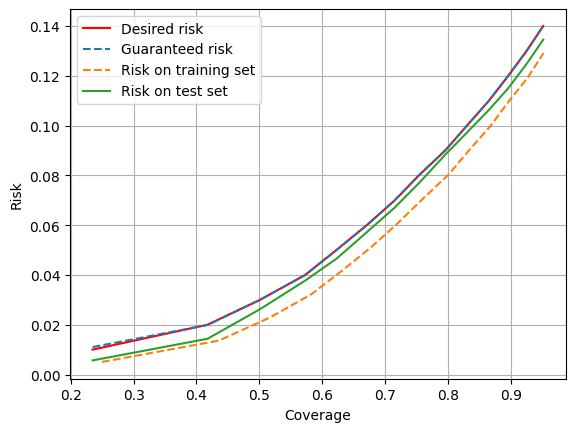

In [5]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.legend()
plt.grid()
plt.show()

### <font color = 'yellow'> 1.2. Binary classification SGR : evolution of guarantees as 0/1 classes imbalance increases

## /!\ load model trained for binary classification ! otherwise model will predict other classes than 0,1

In [6]:
binary_set = sgr_df.loc[sgr_df.y_true.isin([0,1])]
binary_set.shape[0]

5978

In [7]:
all_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(binary_set, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=2800)

    train_set = imbalanced_set.iloc[:1800]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[1000:]

    results = SGR_at_risks(train_set,test_set)
    results['proportion_1'] = proportion_1/100
    all_dfs = pd.concat([all_dfs, results]).reset_index(drop=True)
    

In [8]:
all_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.01,0.015381,0.002225,0.499444,0.002230,0.498333,0.01
1,0.02,0.018951,0.005814,0.668889,0.010664,0.677222,0.01
2,0.03,0.029388,0.013463,0.742778,0.018671,0.743889,0.01
3,0.04,0.041321,0.022917,0.800000,0.030429,0.803333,0.01
4,0.05,0.050385,0.030464,0.838889,0.036818,0.845000,0.01
...,...,...,...,...,...,...,...
695,0.10,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
696,0.11,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
697,0.12,0.079071,0.056174,0.998889,0.067815,0.999444,0.50
698,0.13,0.079071,0.056174,0.998889,0.067815,0.999444,0.50


C:\Users\ejeme\AppData\Local\Temp\ipykernel_18204\692922431.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_18204\692922431.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orange = cm.get_cmap('Oranges')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_18204\692922431.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_gray = cm.get_cmap('Grays')


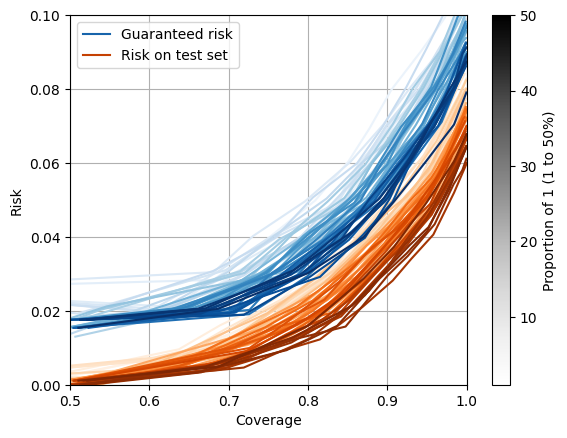

In [9]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')
cmap_gray = cm.get_cmap('Grays')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_dfs.loc[all_dfs.proportion_1 == proportion_1 / 100]

    line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue)
    line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

    lines_guaranteed.append(line1)
    lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Proportion of 1 (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.grid()
plt.xlim(0.5, 1)
plt.ylim(0, 0.1)

plt.show()

A couverture constante, le risque garanti et le risque mesuré sur le jeu de test sont de plus en plus élevés avec l'augmentation du déséquilibre de classe. 

## <font color = 'yellow'> 2. SGR with __type I,II losses__

### <font color = 'yellow'> 2.1. Binary classification SGR

In [18]:
train_set = binary_set.iloc[:int(binary_set.shape[0]/2)]
train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
test_set = binary_set.iloc[int(binary_set.shape[0]/2):]
results = SGR_at_risks(train_set,test_set, loss = 'typeII', delta = 0.1)

results

""


In [11]:
plt.plot(results.test_coverage, results.desired_risk, label = 'Desired risk', c='red')
plt.plot(results.test_coverage, results.risk_bound, label = 'Guaranteed risk',  linestyle='--')
plt.plot(results.train_coverage, results.train_risk, label = 'Risk on training set',  linestyle='--')
plt.plot(results.test_coverage, results.test_risk, label = 'Risk on test set')
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.legend()
plt.grid()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'test_coverage'

### <font color = 'yellow'> 2.2. Binary classif. SGR : evolution of guarantees as 0/1 classes imbalance increases

In [13]:
all_dfs = pd.DataFrame()

for proportion_1 in range(1,51):

    imbalanced_set = sample_with_proportion(binary_set, label_col='y_true',
                                            proportion_1=proportion_1/100,
                                            sample_size=2800)

    train_set = imbalanced_set.iloc[:1800]
    train_set = train_set.sort_values('SR', ascending=True).reset_index(drop=True).copy()
    test_set = imbalanced_set.iloc[1000:]

    results = SGR_at_risks(train_set,test_set, loss = 'typeII')
    results['proportion_1'] = proportion_1/100
    all_dfs = pd.concat([all_dfs, results]).reset_index(drop=True)

    

In [40]:
all_dfs

,desired_risk,risk_bound,train_risk,train_coverage,test_risk,test_coverage,proportion_1
0,0.01,0.011749,0.025424,0.749444,0.012422,0.753889,0.01
1,0.02,0.013611,0.010243,0.998889,0.007732,0.998889,0.01
2,0.03,0.013611,0.010243,0.998889,0.007732,0.998889,0.01
3,0.04,0.013611,0.010243,0.998889,0.007732,0.998889,0.01
4,0.05,0.013611,0.010243,0.998889,0.007732,0.998889,0.01
...,...,...,...,...,...,...,...
695,0.10,0.010834,0.003655,0.998889,0.004032,0.999444,0.50
696,0.11,0.010834,0.003655,0.998889,0.004032,0.999444,0.50
697,0.12,0.010834,0.003655,0.998889,0.004032,0.999444,0.50
698,0.13,0.010834,0.003655,0.998889,0.004032,0.999444,0.50


C:\Users\ejeme\AppData\Local\Temp\ipykernel_18204\2146267291.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blue = cm.get_cmap('Blues')
C:\Users\ejeme\AppData\Local\Temp\ipykernel_18204\2146267291.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_orange = cm.get_cmap('Oranges')


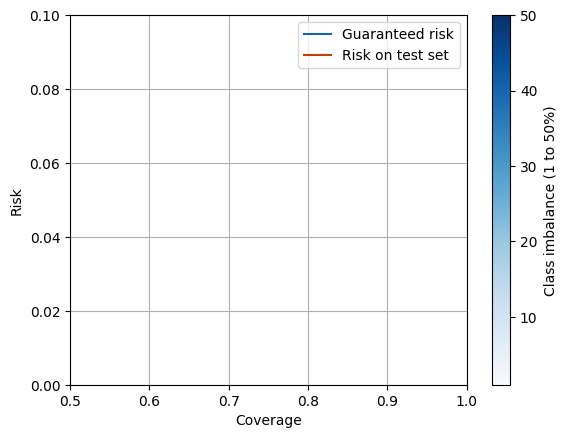

In [17]:
# Choose colormaps
cmap_blue = cm.get_cmap('Blues')
cmap_orange = cm.get_cmap('Oranges')

# Normalize for color mapping (1 to 50)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = cm.ScalarMappable(cmap=cmap_blue, norm=norm)
sm.set_array([])  # Needed for colorbar

# Start plotting
fig, ax = plt.subplots()

# Track line objects for grouping labels
lines_guaranteed = []
lines_test = []

for proportion_1 in range(1, 51):
    norm_value = proportion_1 / 50
    color_blue = cmap_blue(norm_value)
    color_orange = cmap_orange(norm_value)

    results = all_dfs.loc[all_dfs.proportion_1 == proportion_1 / 100]

    if len(results)>0:

        line1, = ax.plot(results.test_coverage, results.risk_bound, color=color_blue)
        line2, = ax.plot(results.test_coverage, results.test_risk, color=color_orange)

        lines_guaranteed.append(line1)
        lines_test.append(line2)

# Add labels just once using proxy artists
proxy_blue = plt.Line2D([0], [0], color=cmap_blue(0.8), label='Guaranteed risk')
proxy_orange = plt.Line2D([0], [0], color=cmap_orange(0.8), label='Risk on test set')
plt.legend(handles=[proxy_blue, proxy_orange])

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Class imbalance (1 to 50%)')

# Labels and formatting
plt.xlabel('Coverage')
plt.ylabel('Risk')
plt.grid()
plt.xlim(0.5, 1)
plt.ylim(0, 0.1)

plt.show()